# SimSiam-UNet
Self-supervised pretraining of the U-Net encoder using SimSiam, followed by supervised fine-tuning for segmentation across multiple label fractions.

**Pipeline:**
1. Pretrain the U-Net encoder with SimSiam (no labels needed)
2. Attach the decoder and fine-tune for segmentation at each label fraction (5%, 10%, 20%, 50%)

## Configuration

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
# Change paths depending on dataset

DATASET_NAME = "ISIC2018"

DATASET_CONFIGS = {
    "KDSB": {
        "train_path": "datasets/KDSB/train/",
        "val_path":   "datasets/KDSB/val/",       # doesn't exist for KDSB -> HAS_VAL will be False
        "test_path":  "datasets/KDSB/test/",
        "img_dir":    "org",             # subfolder holding images, relative to each split path
        "mask_dir":   "gt",              # subfolder holding masks, relative to each split path
        "mask_name":  lambda img_name: img_name,
    },
       "ISIC2018": {
        "train_path": "datasets/ISIC2018/train/",
        "val_path":   "datasets/ISIC2018/val/",
        "test_path":  "datasets/ISIC2018/test/",
        "img_dir":    "org",
        "mask_dir":   "gt",
        "mask_name":  lambda img_name: os.path.splitext(img_name)[0] + "_segmentation.png",
    },
}

cfg = DATASET_CONFIGS[DATASET_NAME]
TRAIN_PATH   = cfg["train_path"]
VAL_PATH     = cfg["val_path"]
TEST_PATH    = cfg["test_path"]
IMG_DIR      = cfg["img_dir"]
MASK_DIR     = cfg["mask_dir"]
mask_name_fn = cfg["mask_name"]


SAVE_DIR     = "saved_models"
SAVE_NP      = "saved_np"

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# Label fractions to sweep during fine-tuning
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.50]

val_split  = 0.3
THRESHOLD  = 0.5

# SimSiam pretraining
PRETRAIN_EPOCHS    = 100
PRETRAIN_BATCH     = 8
PROJECT_DIM        = IMG_HEIGHT // 2
PREDICTOR_DIM      = 64                   # predictor MLP hidden dim
WEIGHT_DECAY       = 5e-4
PRETRAIN_FLG       = False   # False = load saved weights
PRETRAINED_WEIGHTS = f"{DATASET_NAME}_simsiam_encoder.keras"

# Segmentation fine-tuning
FINETUNE_EPOCHS = 200
FINETUNE_BATCH  = 8
TRAIN_FLG       = True      # False = skip fine-tuning

# TEST_MODE: set True to smoke-test the full pipeline cheaply
TEST_MODE = False

# ---- K-Fold Cross-Validation ----
USE_KFOLD       = True   # False = skip CV, only run the single train/val/test split below
N_FOLDS         = 5      # number of folds per label fraction
CV_RANDOM_STATE = 42


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # restrict to the empty GPU

## Imports

In [3]:
import os
import random
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import *
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy
from hausdorff import hausdorff_distance

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_NP,  exist_ok=True)
os.makedirs("logs/fit", exist_ok=True)


I0000 00:00:1786592539.868419 1723262 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## GPU Setup


In [4]:
# ============================================================
# GPU CONFIGURATION
# ============================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs available: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found — running on CPU.")

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())


GPUs available: ['/physical_device:GPU:0']
TensorFlow version: 2.21.0
Built with CUDA: True


## Data Loading

In [5]:
# ---- Detect whether this dataset ships a dedicated validation split ----
HAS_VAL = os.path.isdir(os.path.join(VAL_PATH, IMG_DIR))
print(f"Validation folder found at {VAL_PATH} — will use it for validation."
      if HAS_VAL else
      "No validation folder found — will fall back to splitting train data (val_split).")

x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

if HAS_VAL:
    x_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
    y_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

required_paths = [x_train_path, y_train_path, x_test_path, y_test_path]
if HAS_VAL:
    required_paths += [x_val_path, y_val_path]

def load_split(split_path):
    """Load and resize one split's images + masks using this dataset's naming convention."""
    ids = next(os.walk(os.path.join(split_path, IMG_DIR)))[2][:]
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(ids), total=len(ids)):
        img = imread(os.path.join(split_path, IMG_DIR, id_))[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X[n] = img

        mask = imread(os.path.join(split_path, MASK_DIR, mask_name_fn(id_)))
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y[n][mask[:, :, 0] / 255 > 0.] = 1.

    return X, Y

if all(os.path.exists(p) for p in required_paths):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    if HAS_VAL:
        X_val = np.load(x_val_path)
        Y_val = np.load(y_val_path)
        print(f"Loaded — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")

    X_train, Y_train = load_split(TRAIN_PATH)
    X_test,  Y_test  = load_split(TEST_PATH)
    print(f"Train images: {X_train.shape[0]}, Test images: {X_test.shape[0]}")

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)

    if HAS_VAL:
        X_val, Y_val = load_split(VAL_PATH)
        print(f"Val images: {X_val.shape[0]}")
        np.save(x_val_path, X_val)
        np.save(y_val_path, Y_val)
        print(f"Saved — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")


Validation folder found at datasets/ISIC2018/val/ — will use it for validation.
Found cached arrays, loading...
Loaded — Train: (2594, 256, 256, 3), Val: (100, 256, 256, 3), Test: (1000, 256, 256, 3)


## U-Net Architecture
Identical to BT-UNet and UNet notebooks.

In [6]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False, prefix="dec"):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same',
                            name=f'{prefix}_sepconv_a')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis, name=f'{prefix}_bn_a')(conv)
    conv = Activation('relu', name=f'{prefix}_relu_a')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same',
                            name=f'{prefix}_sepconv_b')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis, name=f'{prefix}_bn_b')(conv)
    conv = Activation('relu', name=f'{prefix}_relu_b')(conv)
    if dropout > 0:
        conv = Dropout(dropout, name=f'{prefix}_drop')(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same', name=f'{prefix}_shortcut')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis, name=f'{prefix}_shortcut_bn')(shortcut)
    return add([shortcut, conv], name=f'{prefix}_add')


def encoder(inputs, prefix="enc"):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for i, f in enumerate(num_filters):
        stage = f'{prefix}_stage{i}'
        a = double_conv_layer(x, 3, f, 0.1, True, prefix=stage)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2), name=f'{stage}_pool')(a)
    return x, skip_connections


def bottleneck(inputs, prefix="bneck"):
    return double_conv_layer(inputs, 3, 256, 0.1, True, prefix=prefix)


def decoder(inputs, skip_connections, prefix="dec"):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        stage = f'{prefix}_stage{i}'
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last", name=f'{stage}_up')(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1, name=f'{stage}_concat')
        x     = double_conv_layer(x_att, 3, f, 0.1, True, prefix=stage)
    return x


def output(inputs, prefix="out"):
    x = Conv2D(1, kernel_size=(1, 1), name=f'{prefix}_conv')(inputs)
    x = BatchNormalization(name=f'{prefix}_bn')(x)
    x = Activation('sigmoid', name=f'{prefix}_sigmoid')(x)
    return x


## SimSiam Pretraining

**How SimSiam works:**
Two augmented views of the same image pass through the shared encoder + projection MLP.
A predictor MLP is applied to one branch only. Stop-gradient on the other branch prevents collapse — no negative pairs or momentum encoder needed.

### Augmentation Pipeline

In [7]:
CROP_TO = IMG_HEIGHT
AUTO    = tf.data.AUTOTUNE
SEED    = 42

def random_resize_crop(image, scale=[0.75, 1.0], crop_size=128):
    image_shape = IMG_HEIGHT
    image = tf.image.resize(image, (image_shape, image_shape))
    size  = tf.random.uniform(shape=(1,), minval=scale[0]*image_shape,
                              maxval=scale[1]*image_shape, dtype=tf.float32)
    size  = tf.cast(size, tf.int32)[0]
    crop  = tf.image.random_crop(image, (size, size, 3))
    return tf.image.resize(crop, (crop_size, crop_size))

def flip_random_crop(image):
    image = tf.image.random_flip_left_right(image)
    return random_resize_crop(image, crop_size=CROP_TO)

def color_jitter(x, strength=0.5):
    x = tf.image.random_brightness(x, max_delta=0.8 * strength)
    x = tf.image.random_contrast(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_saturation(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_hue(x, max_delta=0.2 * strength)
    return tf.clip_by_value(x, 0, 255)

def random_apply(func, x, p):
    return func(x) if tf.random.uniform([], 0, 1) < p else x

def custom_augment(image):
    image = tf.cast(image, tf.float32)
    image = flip_random_crop(image)
    image = random_apply(lambda x: tf.image.rot90(x), image, p=0.5)
    image = random_apply(color_jitter, image, p=0.8)
    return image

ssl_ds_one = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds_two = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds = tf.data.Dataset.zip((ssl_ds_one, ssl_ds_two))

I0000 00:00:1786592542.298757 1723262 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22781 MB memory:  -> device: 0, name: Quadro RTX 6000, pci bus id: 0000:01:00.0, compute capability: 7.5


### LR Schedule (WarmUp + Cosine Decay)
Identical to BT-UNet notebook.

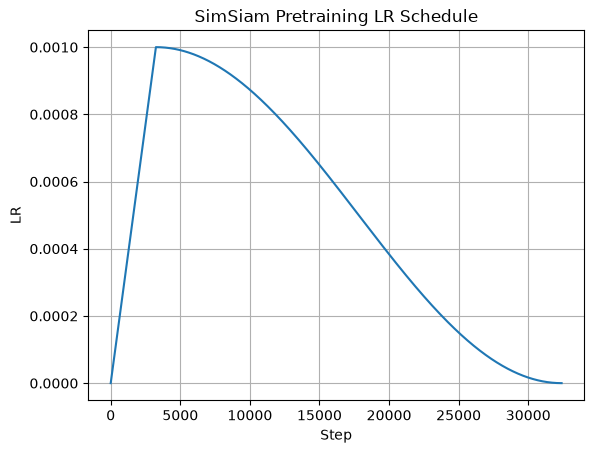

In [8]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base    = learning_rate_base
        self.total_steps           = total_steps
        self.warmup_learning_rate  = warmup_learning_rate
        self.warmup_steps          = warmup_steps
        self.pi                    = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("total_steps must be >= warmup_steps")
        lr = (0.5 * self.learning_rate_base *
              (1 + tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
                          / float(self.total_steps - self.warmup_steps))))
        if self.warmup_steps > 0:
            slope       = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr          = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)


STEPS_PER_EPOCH = len(X_train) // PRETRAIN_BATCH
TOTAL_STEPS     = STEPS_PER_EPOCH * PRETRAIN_EPOCHS
WARMUP_STEPS    = int(PRETRAIN_EPOCHS * 0.1) * STEPS_PER_EPOCH

lr_decayed_fn = WarmUpCosine(
    learning_rate_base=1e-3,
    total_steps=TOTAL_STEPS,
    warmup_learning_rate=0.0,
    warmup_steps=WARMUP_STEPS,
)

plt.plot(lr_decayed_fn(tf.range(TOTAL_STEPS, dtype=tf.float32)))
plt.title("SimSiam Pretraining LR Schedule")
plt.xlabel("Step")
plt.ylabel("LR")
plt.grid()
plt.show()

### Encoder + Projection + Predictor

In [9]:
def projection_head(x, hidden_dim=128):
    """3-layer MLP projection head (same as SimSiam paper)."""
    for i in range(2):
        x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY),
                  name=f"proj_layer_{i}")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    x = Dense(hidden_dim, name="proj_output", kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)   # BN on output, no ReLU (SimSiam paper sec 3)
    return x

def predictor_head(x, hidden_dim=64, output_dim=128):
    """2-layer MLP predictor — only applied to one branch."""
    x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY), name="pred_hidden")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dense(output_dim, name="pred_output", kernel_regularizer=l2(WEIGHT_DECAY))(x)
    return x

def build_simsiam_encoder(shape, proj_dim=128, pred_dim=64):
    inputs = Input(shape)
    s = layers.Rescaling(1.0 / 255)(inputs)
    x, skip_connections = encoder(s)
    x = bottleneck(x)
    trunk_output       = GlobalAvgPool2D()(x)
    projection_outputs = projection_head(trunk_output, hidden_dim=proj_dim)
    model = Model(inputs, projection_outputs, name="simsiam_encoder")
    return model

### SimSiam Model

In [10]:
class SimSiam(tf.keras.Model):
    """
    SimSiam: Exploring Simple Siamese Representation Learning (Chen & He, 2021)

    Key idea: stop-gradient on one branch prevents representational collapse
    without needing negative pairs, large batches, or a momentum encoder.

    Loss = D(p1, z2) / 2 + D(p2, z1) / 2
    where D is negative cosine similarity and z is stop-gradiented.
    """

    def __init__(self, encoder, pred_hidden_dim=64):
        super().__init__()
        self.encoder      = encoder
        self.predictor    = self._build_predictor(encoder.output_shape[-1], pred_hidden_dim)
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def _build_predictor(self, output_dim, hidden_dim):
        inp = Input(shape=(output_dim,))
        x   = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY))(inp)
        x   = BatchNormalization()(x)
        x   = Activation("relu")(x)
        x   = Dense(output_dim, kernel_regularizer=l2(WEIGHT_DECAY))(x)
        return Model(inp, x, name="predictor")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def cosine_loss(self, p, z):
        """Negative cosine similarity. z is stop-gradiented."""
        z = tf.stop_gradient(z)
        p = tf.math.l2_normalize(p, axis=1)
        z = tf.math.l2_normalize(z, axis=1)
        return -tf.reduce_mean(tf.reduce_sum(p * z, axis=1))
        
    def call(self, inputs, training=False):
        if isinstance(inputs, (list, tuple)):
            view_one, view_two = inputs
        else:
            view_one = view_two = inputs
        z1 = self.encoder(view_one, training=training)
        z2 = self.encoder(view_two, training=training)
        p1 = self.predictor(z1, training=training)
        p2 = self.predictor(z2, training=training)
        return p1, p2

    def train_step(self, data):
        view_one, view_two = data

        with tf.GradientTape() as tape:
            # Forward pass — both views through shared encoder
            z1 = self.encoder(view_one, training=True)
            z2 = self.encoder(view_two, training=True)

            # Predictor only on the online branch
            p1 = self.predictor(z1, training=True)
            p2 = self.predictor(z2, training=True)

            # Symmetric loss with stop-gradient on z
            loss = self.cosine_loss(p1, z2) / 2 + self.cosine_loss(p2, z1) / 2

        # Update encoder + predictor together
        trainable_vars = self.encoder.trainable_variables + self.predictor.trainable_variables
        gradients      = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

### Run Pretraining

In [11]:
simsiam_enc = build_simsiam_encoder(
    (IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS),
    proj_dim=PROJECT_DIM,
    pred_dim=PREDICTOR_DIM
    )
simsiam = SimSiam(simsiam_enc, pred_hidden_dim=PREDICTOR_DIM)
simsiam.compile(optimizer=SGD(learning_rate=lr_decayed_fn, momentum=0.9))


if PRETRAIN_FLG:
    print("Pretraining SimSiam encoder...")
    pretrain_history = simsiam.fit(ssl_ds, epochs=PRETRAIN_EPOCHS)
    simsiam.encoder.save(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))
    plt.plot(pretrain_history.history["loss"])
    plt.title("SimSiam Pretraining Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()
else:
    print("Loading pretrained weights...")
    simsiam.encoder.load_weights(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))


Loading pretrained weights...


## Metrics

In [12]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth    = 1.
    y_true_f  = K.flatten(y_true)
    y_pred_f  = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)

## Loss Functions

In [13]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)

## Fine-tuning Loop — All Label Fractions
Rebuilds the full segmentation model fresh for each fraction, loading pretrained encoder weights each time.

In [14]:
def build_segmentation_model(keyname):
    """Rebuild the full segmentation model fresh from the pretrained
    SimSiam encoder, and compile it. Called once per fold and once
    per label fraction so every training run starts from identical
    pretrained weights."""
    pretrained_enc = tf.keras.models.load_model(
        os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS), compile=False
    )
    backbone = tf.keras.Model(
        pretrained_enc.input,
        pretrained_enc.layers[-10].output,
        name="backbone"
    )
    backbone.trainable = True

    # Recover skip connections by name (layers 11, 22, 33, 44)
    new_skip_connections = [
        backbone.get_layer(index=11).output,
        backbone.get_layer(index=22).output,
        backbone.get_layer(index=33).output,
        backbone.get_layer(index=44).output,
    ]

    x       = decoder(backbone.output, new_skip_connections, prefix=f'{keyname}_dec')
    outputs = output(x, prefix=f'{keyname}_out')
    model   = Model(backbone.input, outputs, name=keyname)

    model.compile(
        loss=bce_dice_loss,
        optimizer=Adam(),
        metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                 dice_coeff, MeanAbsoluteError()]
    )
    return model


In [15]:
# Only runs the single train/val/test split when USE_KFOLD is False.
# When USE_KFOLD is True, this is skipped entirely — the K-Fold CV
# section below covers that fraction/model combination instead, so
# nothing is trained twice.
if not USE_KFOLD:
    fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
    FT_EPOCHS = 1  if TEST_MODE else FINETUNE_EPOCHS
    FT_BATCH  = 2  if TEST_MODE else FINETUNE_BATCH
    TEST_CAP  = 10

    all_results = []

    for fraction in fractions_to_run:

        pct      = int(fraction * 100)
        keyname  = f"{DATASET_NAME}_SimSiam-UNET_{pct}pct"
        print(f"\n{'='*60}")
        print(f"Fine-tuning: {keyname}  ({pct}% labelled data)")
        print(f"{'='*60}")

        # ---- Slice the labelled subset ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, TEST_CAP)
            print(f"[TEST_MODE] capped to {n_labelled} samples, {FT_EPOCHS} epoch")
        X_subset   = X_train[:n_labelled]
        Y_subset   = Y_train[:n_labelled]

        # ---- Rebuild backbone from pretrained encoder ----
        model = build_segmentation_model(keyname)

        # ---- Callbacks ----
        log_path   = "logs/"
        cur_date   = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        os.makedirs(log_path + "fit", exist_ok=True)

        callbacks = [
            ModelCheckpoint(
                os.path.join(SAVE_DIR, f"model_{keyname}.keras"),
                monitor='val_loss', verbose=1, save_best_only=True
            ),
            ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10),
            EarlyStopping(monitor='val_loss', verbose=1, patience=20),
            CSVLogger(log_path + keyname + '_' + cur_date + '.log'),
            TensorBoard(log_dir=log_path + "fit/" + keyname + '_' + cur_date, histogram_freq=0),
        ]

        # ---- Train ----
        if TRAIN_FLG:
            history = model.fit(
                X_subset, Y_subset,
                validation_split=val_split,
                batch_size=FT_BATCH,
                epochs=FT_EPOCHS,
                callbacks=callbacks
            )
            plt.plot(history.history['loss'],     label='train')
            plt.plot(history.history['val_loss'], label='val')
            plt.title(f"{keyname} — Loss")
            plt.legend()
            plt.grid()
            plt.show()
        else:
            print("Loading saved weights...")
            model.load_weights(os.path.join(SAVE_DIR, f"model_{keyname}.keras"))

        # ---- Evaluate ----
        if HAS_VAL:
            X_tr_split = X_subset
            Y_tr_split = Y_subset
            X_val_eval = X_val
            Y_val_eval = Y_val
        else:
            split_idx  = int(X_subset.shape[0] * (1 - val_split))
            X_tr_split = X_subset[:split_idx]
            Y_tr_split = Y_subset[:split_idx]
            X_val_eval = X_subset[split_idx:]
            Y_val_eval = Y_subset[split_idx:]

        preds_train = (model.predict(X_tr_split, verbose=1) > THRESHOLD).astype(np.float32)
        preds_full  = (model.predict(X_train,    verbose=1) > THRESHOLD).astype(np.float32)
        preds_val   = (model.predict(X_val_eval, verbose=1) > THRESHOLD).astype(np.float32)
        preds_test  = (model.predict(X_test,     verbose=1) > THRESHOLD).astype(np.float32)

        print("\nTRAIN")
        train_m = evalResult(Y_tr_split.astype(np.float32), preds_train)
        print("\nFULL DATASET")
        full_m  = evalResult(Y_train.astype(np.float32),    preds_full)
        print("\nVALIDATION")
        val_m   = evalResult(Y_val_eval.astype(np.float32),  preds_val)
        print("\nTEST")
        test_m  = evalResult(Y_test.astype(np.float32),     preds_test)

        row = {"Dataset": DATASET_NAME, "Model": keyname, "Label Fraction (%)": pct}
        for split_name, metrics in [("Train", train_m), ("Full", full_m),
                                      ("Val", val_m), ("Test", test_m)]:
            for k, v in metrics.items():
                row[f"{split_name} {k}"] = v
        all_results.append(row)

    print("\nAll label fractions complete.")
else:
    all_results = []
    print("USE_KFOLD is True — skipping single-split loop (see K-Fold CV section below).")


USE_KFOLD is True — skipping single-split loop (see K-Fold CV section below).


## Results Table

In [16]:
results_df = pd.DataFrame(all_results)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("\n================ FINAL RESULTS ================\n")
display(results_df)

os.makedirs("results", exist_ok=True)
results_csv_path = os.path.join("results", f"{DATASET_NAME}_simsiam_results.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Saved to {results_csv_path}")


================ FINAL RESULTS ================



""


Saved to results/ISIC2018_simsiam_results.csv


## K-Fold Cross-Validation
The single train/val/test split above gives one estimate per label fraction, which can be noisy — especially at 5% and 10% labels, where only a handful of images decide the split. This section reruns fine-tuning with `N_FOLDS`-fold cross-validation over each labelled subset, so every fraction gets a mean ± std across multiple independent splits instead of a single number.

Each fold rebuilds the model fresh from the same pretrained SimSiam encoder (via `build_segmentation_model`), trains on `N_FOLDS - 1` folds, and evaluates on the held-out fold plus the untouched external test set. Every fold's model is also saved to disk (`model_SimSiam-UNET_{pct}pct_fold{i}.keras`).

**Ensembling**: once all folds for a label fraction are trained, their `N_FOLDS` models are combined into a single ensemble model that averages their predictions. Because each fold saw a different subset of the labelled data, averaging tends to smooth out individual folds' blind spots and gives a small but real accuracy bump over any single fold. The ensemble is saved as `model_SimSiam-UNET_{pct}pct_ensemble.keras` and is what the Qualitative Visualisation section loads (falling back to the single-split model if no ensemble exists).

Set `USE_KFOLD = False` in the configuration cell to skip this whole section — the single train/val/test split section above will run instead (the two sections are mutually exclusive, so nothing gets trained twice).


In [17]:
cv_fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
CV_EPOCHS = 1 if TEST_MODE else FINETUNE_EPOCHS
CV_BATCH  = 2 if TEST_MODE else FINETUNE_BATCH
CV_TEST_CAP = 10
RECALL_FLOOR = 0.05  # folds with held-out val recall below this are collapsed/degenerate
                     # and are excluded from the ensemble (still logged in cv_results)

cv_results = []
ensemble_results = []

if USE_KFOLD:
    for fraction in cv_fractions_to_run:
        pct = int(fraction * 100)

        # ---- Slice labelled subset (same logic as the single-split loop) ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, CV_TEST_CAP)
        X_subset = X_train[:n_labelled]
        Y_subset = Y_train[:n_labelled]

        n_folds_this = 2 if TEST_MODE else min(N_FOLDS, X_subset.shape[0])
        kf = KFold(n_splits=n_folds_this, shuffle=True, random_state=CV_RANDOM_STATE)

        print(f"\n{'='*60}")
        print(f"K-Fold CV: {pct}% labelled data — {n_folds_this} folds, {X_subset.shape[0]} samples")
        print(f"{'='*60}")

        fold_model_paths = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_subset)):
            keyname = f"{DATASET_NAME}_SimSiam-UNET_{pct}pct_fold{fold_idx}"
            fold_model_path = os.path.join(SAVE_DIR, f"model_{keyname}.keras")
            print(f"\n--- Fold {fold_idx + 1}/{n_folds_this} ({keyname}) ---")

            X_fold_tr, Y_fold_tr   = X_subset[tr_idx],  Y_subset[tr_idx]
            X_fold_val, Y_fold_val = X_subset[val_idx], Y_subset[val_idx]

            model = build_segmentation_model(keyname)

            cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
            callbacks = [
                ModelCheckpoint(
                    fold_model_path,
                    monitor='val_dice_coeff', mode='max', verbose=1, save_best_only=True
                ),
                ReduceLROnPlateau(monitor='val_dice_coeff', mode='max', factor=0.1, patience=10),
                EarlyStopping(monitor='val_dice_coeff', mode='max', verbose=1, patience=20,
                               restore_best_weights=True),
                CSVLogger(f"logs/{keyname}_{cur_date}.log"),
            ]

            if TRAIN_FLG:
                model.fit(
                    X_fold_tr, Y_fold_tr,
                    validation_data=(X_fold_val, Y_fold_val),
                    batch_size=CV_BATCH,
                    epochs=CV_EPOCHS,
                    callbacks=callbacks,
                    verbose=1
                )
            else:
                print("Loading saved fold weights...")
                model.load_weights(fold_model_path)

            preds_fold_val = (model.predict(X_fold_val, verbose=0) > THRESHOLD).astype(np.float32)
            preds_test     = (model.predict(X_test,     verbose=0) > THRESHOLD).astype(np.float32)

            print("  Held-out fold validation:")
            fold_val_m = evalResult(Y_fold_val.astype(np.float32), preds_fold_val)
            print("  External test set:")
            test_m = evalResult(Y_test.astype(np.float32), preds_test)

            row = {"Dataset": DATASET_NAME, "Label Fraction (%)": pct, "Fold": fold_idx}
            for split_name, metrics in [("FoldVal", fold_val_m), ("Test", test_m)]:
                for k, v in metrics.items():
                    row[f"{split_name} {k}"] = v
            cv_results.append(row)
            if fold_val_m['Recall'] >= RECALL_FLOOR:
                fold_model_paths.append(fold_model_path)
            else:
                print(f"  [RECALL FLOOR] Fold {fold_idx} excluded from ensemble "
                      f"(held-out val recall {fold_val_m['Recall']:.4f} < {RECALL_FLOOR})")

            # free GPU memory before the next fold
            del model
            tf.keras.backend.clear_session()

        # ---- Ensemble: average the N_FOLDS fold models into one model ----
        if not fold_model_paths:
            print(f"\n[RECALL FLOOR] All folds excluded at {pct}% labelled data "
                  f"(held-out val recall < {RECALL_FLOOR}) — skipping ensemble.")
            continue
        print(f"\nBuilding ensemble of {len(fold_model_paths)} folds for {pct}% labelled data...")
        fold_models = [
            tf.keras.models.load_model(p, compile=False) for p in fold_model_paths
        ]
        ensemble_input   = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
        fold_outputs     = [m(ensemble_input) for m in fold_models]
        averaged_output  = tf.keras.layers.Average()(fold_outputs) if len(fold_outputs) > 1 else fold_outputs[0]
        ensemble_keyname = f"{DATASET_NAME}_SimSiam-UNET_{pct}pct_ensemble"
        ensemble_model   = tf.keras.Model(ensemble_input, averaged_output, name=ensemble_keyname)

        ensemble_path = os.path.join(SAVE_DIR, f"model_{ensemble_keyname}.keras")
        ensemble_model.save(ensemble_path)
        print(f"Saved ensemble to {ensemble_path}")

        preds_ensemble_test = (ensemble_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)
        print("  Ensemble — external test set:")
        ensemble_test_m = evalResult(Y_test.astype(np.float32), preds_ensemble_test)

        erow = {"Dataset": DATASET_NAME, "Label Fraction (%)": pct, "Folds Combined": len(fold_model_paths)}
        for k, v in ensemble_test_m.items():
            erow[f"Test {k}"] = v
        ensemble_results.append(erow)

        del fold_models, ensemble_model
        tf.keras.backend.clear_session()

    print("\nK-fold cross-validation and ensembling complete.")
else:
    print("USE_KFOLD is False — skipping cross-validation and ensembling (single-split results are in the section above).")



K-Fold CV: 5% labelled data — 5 folds, 129 samples

--- Fold 1/5 (ISIC2018_SimSiam-UNET_5pct_fold0) ---
Epoch 1/200


I0000 00:00:1786592561.141301 1723684 service.cc:153] XLA service 0x753cd0137fd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786592561.141335 1723684 service.cc:161]   StreamExecutor [0]: Quadro RTX 6000, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786592561.562888 1723684 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786592563.391001 1723684 cuda_dnn.cc:461] Loaded cuDNN version 92400
E0000 00:00:1786592568.300898 1723684 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786592570.638936 1723684 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:17865925

 3/13 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5531 - dice_coeff: 0.3700 - loss: 0.6761 - mean_absolute_error: 0.4800 - mean_io_u: 0.3707 - precision: 0.3064 - recall: 0.5738 

I0000 00:00:1786592594.867023 1723684 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6412 - dice_coeff: 0.3977 - loss: 0.6241 - mean_absolute_error: 0.4407 - mean_io_u: 0.3803 - precision: 0.3684 - recall: 0.6828

...

  Held-out fold validation:
  Acc=0.7546  Prec=0.4797  Rec=0.8529  MeanIoU=0.5691  Dice=0.6403  HD=8.8801  MyIoU=0.0975  MAE=0.2454
  External test set:
  Acc=0.6844  Prec=0.4799  Rec=0.7941  MeanIoU=0.5071  Dice=0.6015  HD=10.5566  MyIoU=0.0702  MAE=0.3156

Building ensemble of 5 folds for 10% labelled data...
Saved ensemble to saved_models/model_ISIC2018_SimSiam-UNET_10pct_ensemble.keras
  Ensemble — external test set:
  Acc=0.8914  Prec=0.8169  Rec=0.8156  MeanIoU=0.7732  Dice=0.8160  HD=6.0310  MyIoU=0.4468  MAE=0.1086

K-Fold CV: 20% labelled data — 5 folds, 518 samples

--- Fold 1/5 (ISIC2018_SimSiam-UNET_20pct_fold0) ---
Epoch 1/200
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7284 - dice_coeff: 0.4292 - loss: 0.5797 - mean_absolute_error: 0.4090 - mean_io_u: 0.3781 - precision: 0.4657 - recall: 0.7071

E0000 00:00:1786594132.707114 1723680 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786594134.144776 1723680 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786594135.590234 1723680 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7292 - dice_coeff: 0.4296 - loss: 0.5791 - mean_absolute_error: 0.4086 - mean_io_u: 0.3782 - precision: 0.4668 - recall: 0.7076
Epoch 1: val_dice_coeff improved from None to 0.46629, saving model to saved_models/model_ISIC2018_SimSiam-UNET_20pct_fold0.keras

Epoch 1: finished saving model to saved_models/model_ISIC2018_SimSiam-UNET_20pct_fold0.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 58s 662ms/step - accuracy: 0.7733 - dice_coeff: 0.4489 - loss: 0.5508 - mean_absolute_error: 0.3913 - mean_io_u: 0.3789 - precision: 0.5227 - recall: 0.7351 - val_accuracy: 0.6618 - val_dice_coeff: 0.4663 - val_loss: 0.6837 - val_mean_absolute_error: 0.3875 - val_mean_io_u: 0.4042 - val_precision: 0.3786 - val_recall: 0.8326 - learning_rate: 0.0010
Epoch 2/200
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8143 - dice_coeff: 0.4704 - loss: 0.5220 - mean_absolute_error: 0.3688 - mean_io_u: 0.3789 - precision: 0.5889 - recall: 0.7793
Epoch 2: val_dice_coe

E0000 00:00:1786596619.034920 1723684 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786596620.423506 1723684 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786596620.965452 1723684 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.7681 - dice_coeff: 0.4425 - loss: 0.5582 - mean_absolute_error: 0.3942 - mean_io_u: 0.3803 - precision: 0.5136 - recall: 0.7438
Epoch 1: val_dice_coeff improved from None to 0.48267, saving model to saved_models/model_ISIC2018_SimSiam-UNET_50pct_fold0.keras

Epoch 1: finished saving model to saved_models/model_ISIC2018_SimSiam-UNET_50pct_fold0.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 62s 297ms/step - accuracy: 0.8142 - dice_coeff: 0.4678 - loss: 0.5245 - mean_absolute_error: 0.3698 - mean_io_u: 0.3814 - precision: 0.5803 - recall: 0.7824 - val_accuracy: 0.7667 - val_dice_coeff: 0.4827 - val_loss: 0.5285 - val_mean_absolute_error: 0.3890 - val_mean_io_u: 0.3787 - val_precision: 0.5110 - val_recall: 0.8873 - learning_rate: 0.0010
Epoch 2/200
129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8695 - dice_coeff: 0.5103 - loss: 0.4703 - mean_absolute_error: 0.3288 - mean_io_u: 0.3825 - precision: 0.6834 - recall: 0.8290
Epoch 2: val_di

Per-fold results:


,Dataset,Label Fraction (%),Fold,FoldVal Accuracy,FoldVal Precision,FoldVal Recall,FoldVal MeanIoU,FoldVal Dice,FoldVal HD,FoldVal MyIoU,FoldVal MAE,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,ISIC2018,5,0,0.6618,0.4103,0.8331,0.4764,0.5913,9.6305,0.0596,0.3382,0.6988,0.4943,0.7850,0.5216,0.6159,9.9618,0.0914,0.3012
1,ISIC2018,5,1,0.7933,0.6739,0.8448,0.6501,0.7091,7.9253,0.1283,0.2067,0.6629,0.4609,0.8219,0.4868,0.5929,10.1698,0.0758,0.3371
2,ISIC2018,5,2,0.6087,0.2607,0.9283,0.4018,0.5118,9.7067,0.0983,0.3913,0.6656,0.4643,0.8477,0.4911,0.5954,10.2678,0.0817,0.3344
3,ISIC2018,5,3,0.6187,0.3578,0.8881,0.4333,0.5431,10.0295,0.0536,0.3813,0.5750,0.3993,0.8654,0.4024,0.5469,10.9489,0.0433,0.4250
4,ISIC2018,5,4,0.9620,0.8799,0.9324,0.8903,0.8250,4.6631,0.5480,0.0380,0.8870,0.8556,0.7433,0.7578,0.8044,6.0688,0.4612,0.1130
5,ISIC2018,10,0,0.9369,0.8620,0.8715,0.8427,0.7925,5.4370,0.5237,0.0631,0.8906,0.8263,0.7981,0.7701,0.8083,5.9578,0.4790,0.1094
6,ISIC2018,10,1,0.7479,0.4270,0.8236,0.5452,0.5810,8.5367,0.0597,0.2521,0.6610,0.4602,0.8437,0.4861,0.5950,10.6130,0.0414,0.3390
7,ISIC2018,10,2,0.9306,0.9479,0.8322,0.8504,0.8667,5.5593,0.5487,0.0694,0.8973,0.8557,0.7852,0.7798,0.8275,5.9162,0.4871,0.1027
8,ISIC2018,10,3,0.9526,0.9071,0.8363,0.8570,0.8422,5.0352,0.5266,0.0474,0.8993,0.8674,0.7786,0.7824,0.8313,5.9219,0.4825,0.1007
9,ISIC2018,10,4,0.7546,0.4797,0.8529,0.5691,0.6403,8.8801,0.0975,0.2454,0.6844,0.4799,0.7941,0.5071,0.6015,10.5566,0.0702,0.3156



Mean +/- std across folds:


FoldVal Accuracy        FoldVal Precision         \
                                        mean    std              mean    std   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                            0.7289 0.1497            0.5165 0.2543   
         10                           0.8645 0.1037            0.7248 0.2503   
         20                           0.9429 0.0067            0.9176 0.0098   
         50                           0.9478 0.0050            0.9149 0.0142   

                            FoldVal Recall        FoldVal MeanIoU         \
                                      mean    std            mean    std   
Dataset  Label Fraction (%)                                                
ISIC2018 5                          0.8853 0.0459          0.5704 0.2030   
         10                         0.8433 0.0190          0.7329 0.1607   
         20                         0.8353 0.0387          0.8526 0.0169   
         50                         0.8610 0.0159          0.8657 0.0104   

                            FoldVal Dice        FoldVal HD         \
                                    mean    std       mean    std   
Dataset  Label Fraction (%)                                         
ISIC2018 5                        0.6361 0.1295     8.3910 2.2398   
         10                       0.7445 0.1269     6.6897 1.8570   
         20                       0.8592 0.0132     5.0426 0.1314   
         50                       0.8713 0.0120     4.9286 0.1012   

                            FoldVal MyIoU        FoldVal MAE         \
                                     mean    std        mean    std   
Dataset  Label Fraction (%)                                           
ISIC2018 5                         0.1775 0.2093      0.2711 0.1497   
         10                        0.3512 0.2494      0.1355 0.1037   
         20                        0.5780 0.0187      0.0571 0.0067   
         50                        0.6157 0.0262      0.0522 0.0050   

                            Test Accuracy        Test Precision         \
                                     mean    std           mean    std   
Dataset  Label Fraction (%)                                              
ISIC2018 5                         0.6978 0.1152         0.5349 0.1826   
         10                        0.8065 0.1225         0.6979 0.2087   
         20                        0.9061 0.0016         0.8671 0.0042   
         50                        0.9125 0.0028         0.8588 0.0065   

                            Test Recall        Test MeanIoU        Test Dice  \
                                   mean    std         mean    std      mean   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                       0.8127 0.0492       0.5319 0.1338    0.6311   
         10                      0.8000 0.0256       0.6651 0.1541    0.7327   
         20                      0.8060 0.0025       0.7970 0.0028    0.8402   
         50                      0.8430 0.0101       0.8119 0.0055    0.8524   

                                   Test HD        Test MyIoU        Test MAE  \
                               std    mean    std       mean    std     mean   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                  0.1001  9.4834 1.9444     0.1507 0.1745   0.3022   
         10                 0.1231  7.7931 2.5486     0.3121 0.2341   0.1935   
         20                 0.0036  5.8393 0.0567     0.5031 0.0229   0.0939   
         50                 0.0043  5.7430 0.0828     0.5217 0.0107   0.0875   

                                    
                               std  
Dataset  Label Fraction (%)         
ISIC2018 5                  0.1152  
         10                 0.1225  
         20                 0.0016  
         50                 0.0028

Saved to results/ISIC2018_simsiam_cv_results.csv and results/ISIC2018_simsiam_cv_summary.csv


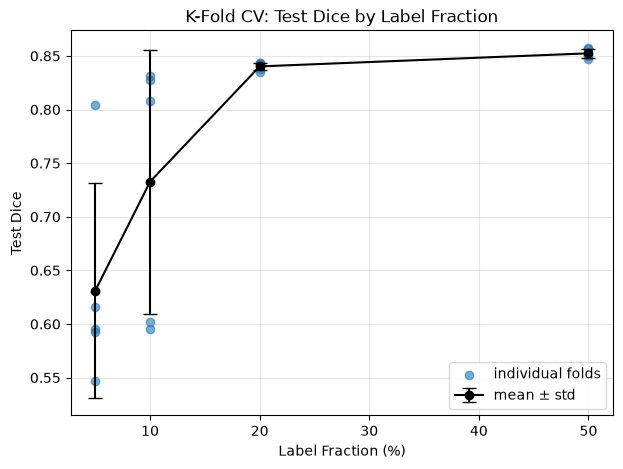


Ensemble results (one row per label fraction, averaged over its fold models):


,Dataset,Label Fraction (%),Folds Combined,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,ISIC2018,5,5,0.6872,0.4835,0.8368,0.5131,0.6233,9.7460,0.1429,0.3128
1,ISIC2018,10,5,0.8914,0.8169,0.8156,0.7732,0.8160,6.0310,0.4468,0.1086
2,ISIC2018,20,5,0.9115,0.8816,0.8095,0.8069,0.8498,5.5566,0.5699,0.0885
3,ISIC2018,50,5,0.9184,0.8734,0.8468,0.8226,0.8630,5.4334,0.5827,0.0816


Saved to results/ISIC2018_simsiam_ensemble_results.csv

Ensemble vs. average single fold:


,Ensemble Test Dice,Avg Single-Fold Test Dice
Label Fraction (%),,
5,0.6233,0.6311
10,0.8160,0.7327
20,0.8498,0.8402
50,0.8630,0.8524


In [18]:
if USE_KFOLD and cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("Per-fold results:")
    display(cv_df)

    # Mean +/- std across folds, per label fraction
    metric_cols = [c for c in cv_df.columns if c not in ("Dataset", "Label Fraction (%)", "Fold")]
    group_cols = [c for c in ("Dataset", "Label Fraction (%)") if c in cv_df.columns]
    cv_summary = cv_df.groupby(group_cols)[metric_cols].agg(['mean', 'std'])
    print("\nMean +/- std across folds:")
    display(cv_summary)

    os.makedirs("results", exist_ok=True)
    cv_df.to_csv(os.path.join("results", f"{DATASET_NAME}_simsiam_cv_results.csv"), index=False)
    cv_summary.to_csv(os.path.join("results", f"{DATASET_NAME}_simsiam_cv_summary.csv"))
    print(f"Saved to results/{DATASET_NAME}_simsiam_cv_results.csv and results/{DATASET_NAME}_simsiam_cv_summary.csv")

    # Sanity-check plot: Test Dice across folds per label fraction
    fractions_sorted = sorted(cv_df["Label Fraction (%)"].unique())
    plt.figure(figsize=(7, 5))
    for i, pct in enumerate(fractions_sorted):
        sub = cv_df[cv_df["Label Fraction (%)"] == pct]
        plt.scatter([pct] * len(sub), sub["Test Dice"], alpha=0.6, color='tab:blue',
                    label="individual folds" if i == 0 else None)
    means = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean().loc[fractions_sorted]
    stds  = cv_df.groupby("Label Fraction (%)")["Test Dice"].std().loc[fractions_sorted]
    plt.errorbar(fractions_sorted, means.values, yerr=stds.values, fmt='o-',
                 color='black', capsize=5, label="mean ± std")
    plt.xlabel("Label Fraction (%)")
    plt.ylabel("Test Dice")
    plt.title("K-Fold CV: Test Dice by Label Fraction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    cv_df = pd.DataFrame()

if USE_KFOLD and ensemble_results:
    ensemble_df = pd.DataFrame(ensemble_results)
    print("\nEnsemble results (one row per label fraction, averaged over its fold models):")
    display(ensemble_df)

    os.makedirs("results", exist_ok=True)
    ensemble_df.to_csv(os.path.join("results", f"{DATASET_NAME}_simsiam_ensemble_results.csv"), index=False)
    print(f"Saved to results/{DATASET_NAME}_simsiam_ensemble_results.csv")

    # Compare: single best fold's Test Dice (mean across folds) vs. the ensemble's Test Dice
    if not cv_df.empty:
        fold_mean_dice = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean()
        compare_df = ensemble_df[["Label Fraction (%)", "Test Dice"]].rename(
            columns={"Test Dice": "Ensemble Test Dice"}
        ).set_index("Label Fraction (%)")
        compare_df["Avg Single-Fold Test Dice"] = fold_mean_dice
        print("\nEnsemble vs. average single fold:")
        display(compare_df)
else:
    ensemble_df = pd.DataFrame()


## Qualitative Visualisation

Loaded: saved_models/model_ISIC2018_SimSiam-UNET_50pct_ensemble.keras


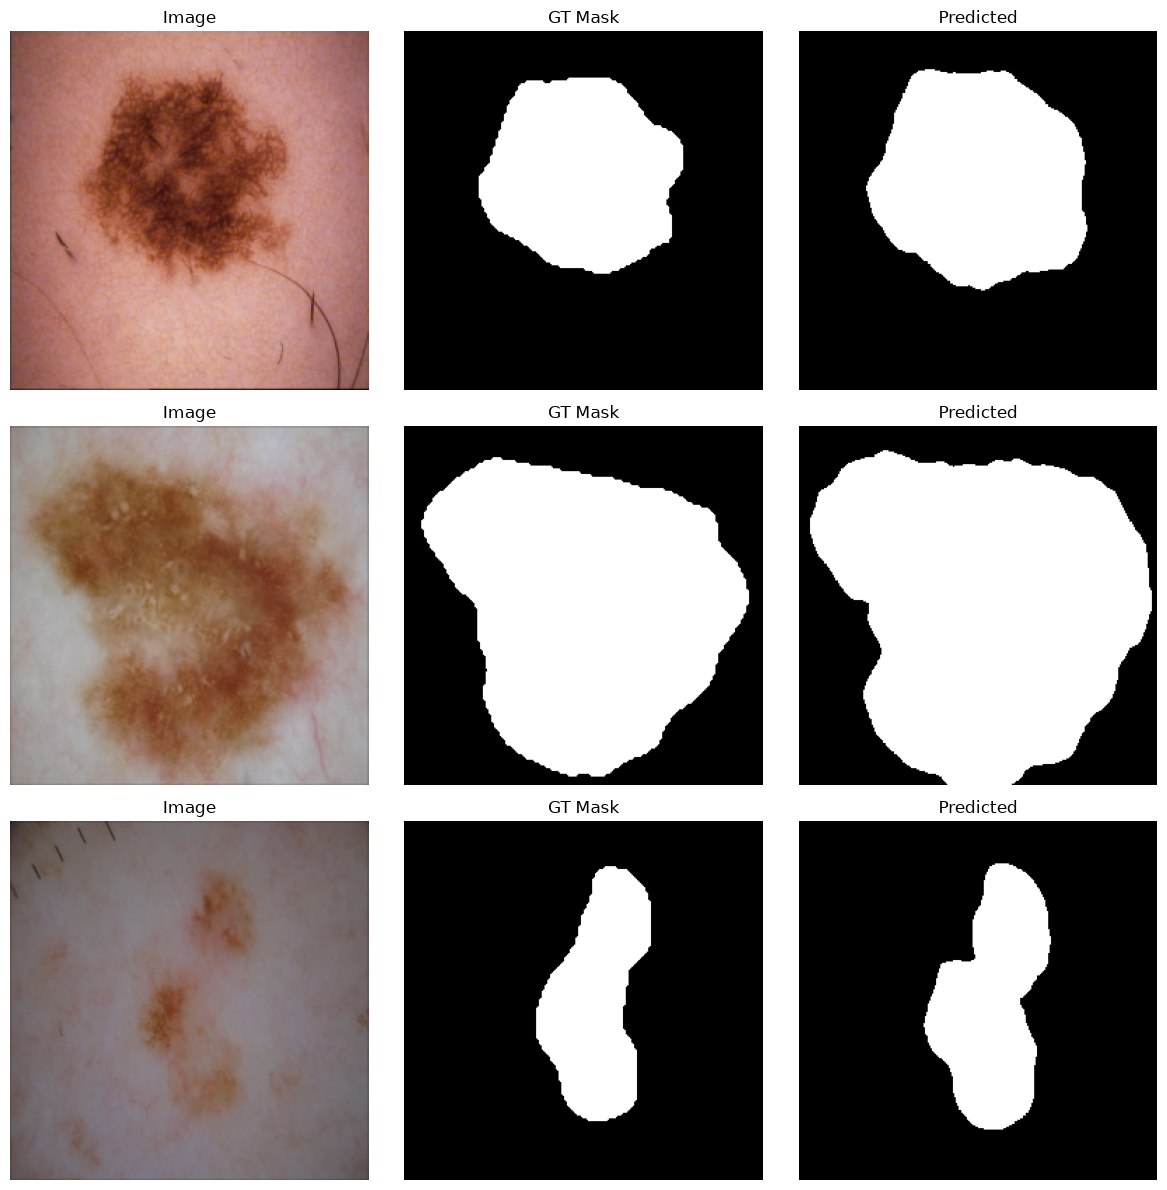

In [19]:
# Reload the best available model (50% fraction) for visualisation.
# Prefers the K-fold ensemble if one was built; falls back to the single-split
# model (e.g. if USE_KFOLD was False).
ensemble_path_vis = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_SimSiam-UNET_50pct_ensemble.keras")
single_path_vis   = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_SimSiam-UNET_50pct.keras")
model_path_vis    = ensemble_path_vis if os.path.exists(ensemble_path_vis) else single_path_vis

best_model = tf.keras.models.load_model(model_path_vis, compile=False)
print(f"Loaded: {model_path_vis}")
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));         axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray'); axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()